# TifVolumeSliceDataset — Visualisation

This notebook explores the `TifVolumeSliceDataset` from `ladiff.datasets`.
It loads a set of time-resolved 4D TIFF volumes stored as a sequence of
`.tif` files, each containing 128 slices of a 528 × 528 volume, and
visualises the resulting 2D slice dataset.

**Dataset path:** `/myhome/data/sdate/shared/time_resolved/212_Wunderkerze2/timesteps`  
**File naming:** `212_Wunderkerze2_rotate_NNNNN.tif`

## 1. Imports and Setup

In [30]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import lovely_tensors as lt
lt.monkey_patch()

# ── Project path ──────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from ladiff.datasets import TifVolumeSliceDataset

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

print(f"ladiff datasets imported ✅")

ladiff datasets imported ✅


## 2. Configuration

In [31]:
DATA_DIR = Path('/myhome/data/sdate/shared/time_resolved/212_Wunderkerze2/timesteps')

# Starting file — change to any file in the directory
START_FILE = DATA_DIR / '212_Wunderkerze2_rotate_04001.tif'

# Number of consecutive tif files to load (None = just START_FILE)
FILE_RANGE = 3          # 2 files → 256 slices

# Resize each slice to this square size (None = native 528×528)
RESIZE = None

# Normalisation range (None = auto from data min/max)
NORMALIZE_RANGE = None

print(f"Start file : {START_FILE.name}")
print(f"File range : {FILE_RANGE}")
print(f"Resize     : {RESIZE}")
print(f"Norm range : {NORMALIZE_RANGE}")

Start file : 212_Wunderkerze2_rotate_04001.tif
File range : 3
Resize     : None
Norm range : None


## 3. Build Dataset

In [32]:
dataset = TifVolumeSliceDataset(
    data_path=START_FILE,
    file_range=FILE_RANGE,
    resize=RESIZE,
    normalize_range=NORMALIZE_RANGE,
)

print(dataset)
print()
print(f"Files loaded:")
for i, (f, n) in enumerate(zip(dataset.files, dataset.slices_per_file)):
    print(f"  [{i}] {f.name}  →  {n} slices")
print(f"\nTotal slices : {len(dataset)}")
print(f"Image size   : {dataset.image_size}")
print(f"Norm range   : [{dataset.norm_min:.4g}, {dataset.norm_max:.4g}]")

TifVolumeSliceDataset(files=3, total_slices=384, slices_per_file=[128, 128, 128], image_size=native (528, 528), norm=[0, 4.62e+04])

Files loaded:
  [0] 212_Wunderkerze2_rotate_04001.tif  →  128 slices
  [1] 212_Wunderkerze2_rotate_04010.tif  →  128 slices
  [2] 212_Wunderkerze2_rotate_04020.tif  →  128 slices

Total slices : 384
Image size   : (528, 528)
Norm range   : [0, 4.62e+04]


## 4. Inspect a Single Slice

Slice index : 192
Shape       : torch.Size([528, 528])
dtype       : torch.float32
Value range : [0.0000, 0.8988]


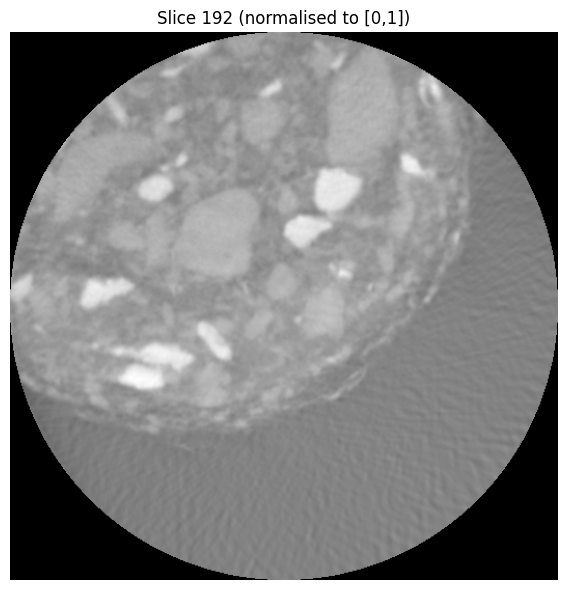

In [33]:
SAMPLE_IDX = len(dataset) // 2  # middle slice

sample = dataset[SAMPLE_IDX]  # float32 tensor (H, W)
print(f"Slice index : {SAMPLE_IDX}")
print(f"Shape       : {sample.shape}")
print(f"dtype       : {sample.dtype}")
print(f"Value range : [{sample.min():.4f}, {sample.max():.4f}]")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(sample.numpy(), cmap='gray')
ax.set_title(f'Slice {SAMPLE_IDX} (normalised to [0,1])')
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Browse Slices Across the Volume

Show evenly spaced slices from the first loaded file.

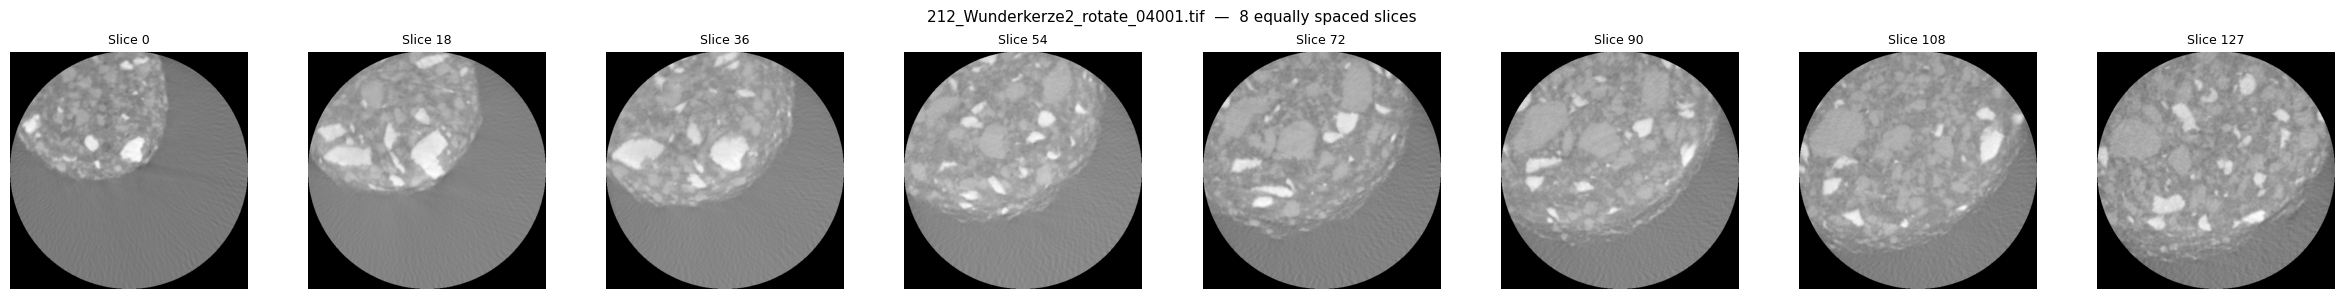

In [34]:
N_SHOW = 8  # number of slices to display
n_slices_file0 = dataset.slices_per_file[0]
show_indices = np.linspace(0, n_slices_file0 - 1, N_SHOW, dtype=int)

fig, axes = plt.subplots(1, N_SHOW, figsize=(3 * N_SHOW, 3))
for col, idx in enumerate(show_indices):
    img = dataset[int(idx)].numpy()
    axes[col].imshow(img, cmap='gray')
    axes[col].set_title(f'Slice {idx}', fontsize=9)
    axes[col].axis('off')
plt.suptitle(f'{dataset.files[0].name}  —  {N_SHOW} equally spaced slices', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Compare Across Files

For each loaded file show the same slice index to visualise temporal change.

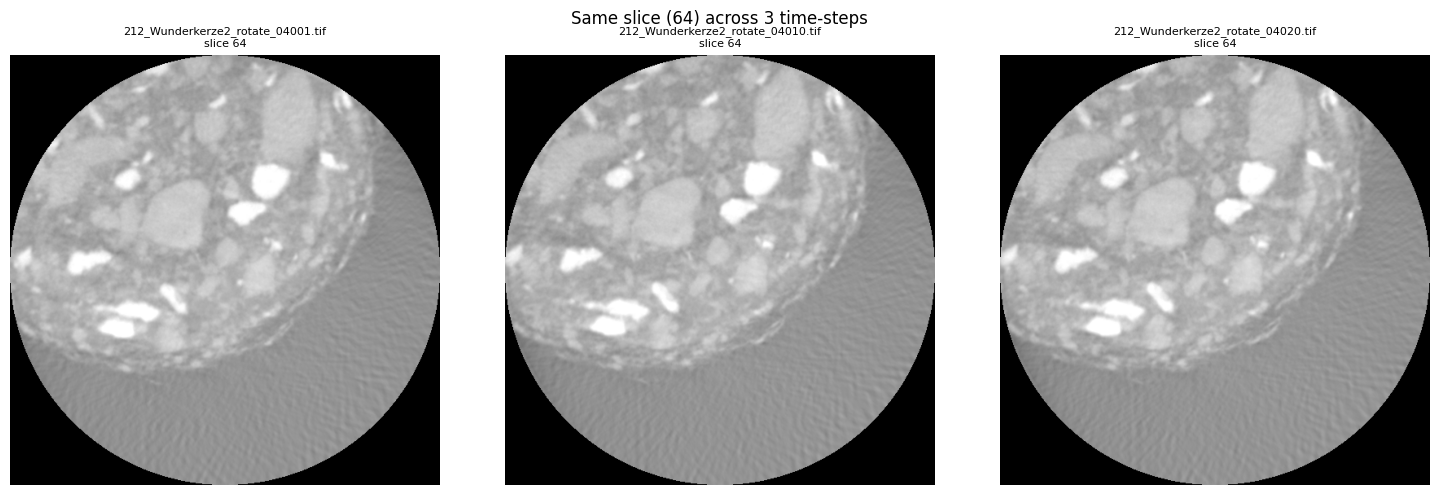

In [ ]:
COMPARE_SLICE = dataset.slices_per_file[0] // 2  # middle slice of first file
n_files = dataset.num_files

fig, axes = plt.subplots(1, n_files, figsize=(5 * n_files, 5))
if n_files == 1:
    axes = [axes]

for file_idx in range(n_files):
    global_idx = int(dataset._cumulative[file_idx]) + COMPARE_SLICE
    img = dataset[global_idx].numpy()
    vmin, vmax = np.percentile(img, [1, 99])
    axes[file_idx].imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    axes[file_idx].set_title(f'{dataset.files[file_idx].name}\nslice {COMPARE_SLICE}', fontsize=8)
    axes[file_idx].axis('off')

plt.suptitle(f'Same slice ({COMPARE_SLICE}) across {n_files} time-steps', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Histogram of Pixel Intensities

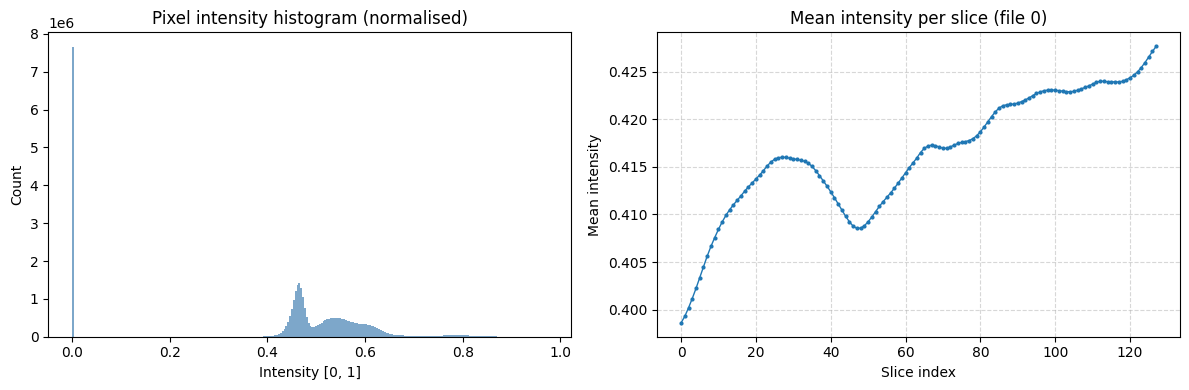

In [ ]:
# Grab the full volume of the first file as a tensor
vol0 = dataset.get_volume(0)  # (N, H, W)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vol0.numpy().ravel(), bins=256, color='steelblue', alpha=0.7)
axes[0].set_title('Pixel intensity histogram (normalised)')
axes[0].set_xlabel('Intensity [0, 1]')
axes[0].set_ylabel('Count')

# Depth profile: mean intensity per slice
mean_per_slice = vol0.mean(dim=[1, 2]).numpy()
axes[1].plot(mean_per_slice, marker='o', markersize=2, linewidth=1)
axes[1].set_title('Mean intensity per slice (file 0)')
axes[1].set_xlabel('Slice index')
axes[1].set_ylabel('Mean intensity')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Dataset with Resize

Demonstrate loading with downsampled resolution.

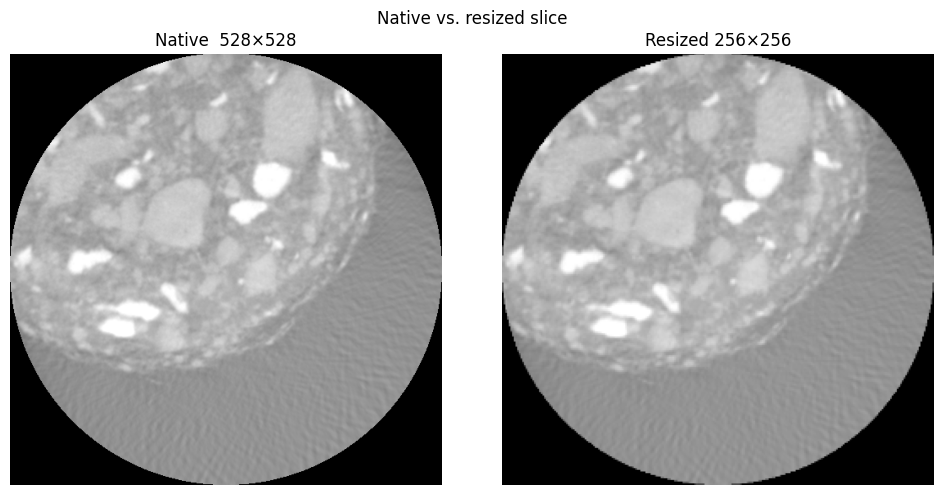

In [ ]:
RESIZE_TARGET = 256

dataset_resized = TifVolumeSliceDataset(
    data_path=START_FILE,
    file_range=1,
    resize=RESIZE_TARGET,
    normalize_range=(dataset.norm_min, dataset.norm_max),  # reuse same norm for fair comparison
)

idx = len(dataset_resized) // 2
img_orig   = dataset[idx].numpy()
img_resized = dataset_resized[idx].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
vmin, vmax = np.percentile(img_orig, [1, 99])

axes[0].imshow(img_orig, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Native  {img_orig.shape[0]}×{img_orig.shape[1]}')
axes[0].axis('off')

axes[1].imshow(img_resized, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Resized {img_resized.shape[0]}×{img_resized.shape[1]}')
axes[1].axis('off')

plt.suptitle('Native vs. resized slice', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Dataset with Custom Normalisation Range

Pass an explicit `normalize_range` to clip/scale intensity.

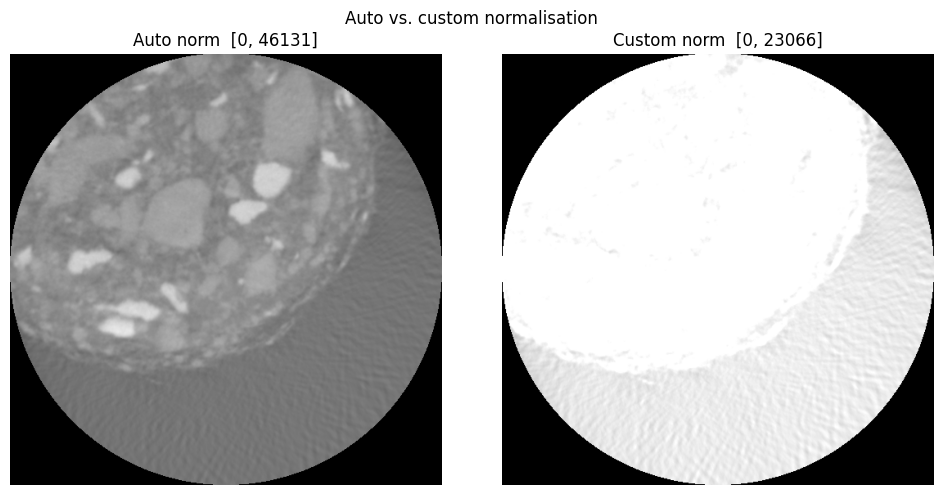

In [ ]:
# Clip to a manually chosen window (useful e.g. to highlight soft tissue)
NORM_MIN = 0.0
NORM_MAX = dataset.norm_max * 0.5  # use lower half of full dynamic range

dataset_custom_norm = TifVolumeSliceDataset(
    data_path=START_FILE,
    file_range=1,
    resize=None,
    normalize_range=(NORM_MIN, NORM_MAX),
)

idx = len(dataset_custom_norm) // 2
img_auto   = dataset[idx].numpy()
img_custom = dataset_custom_norm[idx].numpy().clip(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_auto, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Auto norm  [{dataset.norm_min:.0f}, {dataset.norm_max:.0f}]')
axes[0].axis('off')

axes[1].imshow(img_custom, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Custom norm  [{NORM_MIN:.0f}, {NORM_MAX:.0f}]')
axes[1].axis('off')

plt.suptitle('Auto vs. custom normalisation', fontsize=12)
plt.tight_layout()
plt.show()